# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [2]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN
symbol = 'NVDA.csv'
df = pd.read_csv('data/raw/NVDA.csv',index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.sort_index()
df.columns = [col.lower() for col in df.columns]
df['volume'].fillna(0)
display(df)


,adj_close,close,high,low,open,volume,symbol
date,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA
...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA


In [3]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [4]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
#return_1     = ...
#return_5     = ...
#log_return_1 = ...

df['return_1']     = df['close'].pct_change(1)
df['return_5']     = df['close'].pct_change(5)
df['log_return_1'] = np.log(df['close']/df['close'].shift(1))
display(df)

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1
date,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927
...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890


## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [5]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = df['close'].rolling(20).mean()
df['sma_50']      = df['close'].rolling(50).mean()
df['sma_200']     = df['close'].rolling(200).mean()
df['sma_ratio_20'] = df['close'] / df['close'].rolling(20).mean()
df['sma_ratio_50'] = df['close'] / df['close'].rolling(50).mean()
display(df)

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,sma_20,sma_50,sma_200,sma_ratio_20,sma_ratio_50
date,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034,NaN,NaN,NaN,NaN,NaN
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787,NaN,NaN,NaN,NaN,NaN
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609,NaN,NaN,NaN,NaN,NaN
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,216.753501,200.264800,187.86705,1.035093,1.120317
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,217.970502,201.267201,188.07105,1.022248,1.107086
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,218.883002,202.049401,188.24255,0.981118,1.062859


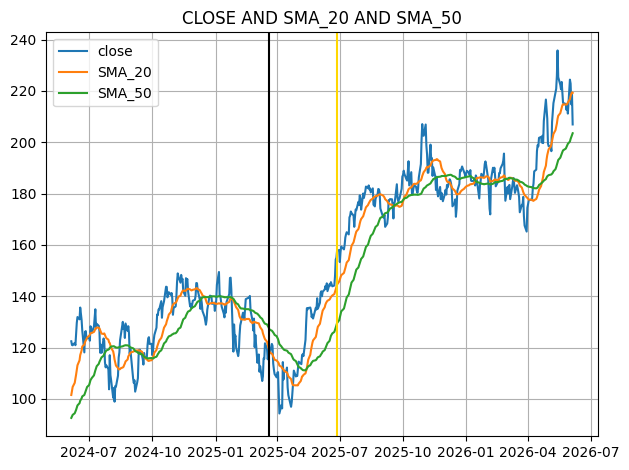

In [6]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.loc[df.index >= df.index.max() - pd.DateOffset(years=2)]
cross  = recent['sma_50'] - recent['sma_200']
golden = (cross>0) & (cross.shift(1) <= 0)
death  = (cross<0) & (cross.shift(1) >= 0)
# Plot Graph
plt.plot(recent['close'],label='close')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['sma_50'],label='SMA_50')
plt.grid(True)
for a in recent[golden].index:
    plt.axvline(a,color='gold')
for a in recent[death].index:
    plt.axvline(a,color='black')
plt.title('CLOSE AND SMA_20 AND SMA_50')
plt.tight_layout()
plt.legend()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [7]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20
df['ema_12']       = df['close']*(2/13) + df['close'].shift(1)*(1-2/13)
df['ema_20']       = df['close']*(2/21) + df['close'].shift(1)*(1-2/21)
df['ema_26']       = df['close']*(2/27) + df['close'].shift(1)*(1-2/27)
df['ema_ratio_20'] = df['close'] / df['ema_20'] -1
display(df)

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,sma_20,sma_50,sma_200,sma_ratio_20,sma_ratio_50,ema_12,ema_20,ema_26,ema_ratio_20
date,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034,NaN,NaN,NaN,NaN,NaN,0.501942,0.502440,0.502620,-0.015306
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787,NaN,NaN,NaN,NaN,NaN,0.492442,0.493321,0.493639,-0.027510
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609,NaN,NaN,NaN,NaN,NaN,0.479558,0.479631,0.479657,-0.002358
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927,NaN,NaN,NaN,NaN,NaN,0.481269,0.480214,0.479833,0.033913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,216.753501,200.264800,187.86705,1.035093,1.120317,213.173846,212.399047,212.119259,0.056314
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,217.970502,201.267201,188.07105,1.022248,1.107086,224.123079,224.213335,224.245927,-0.006214
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,218.883002,202.049401,188.24255,0.981118,1.062859,221.578468,222.051435,222.222229,-0.032882


,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,sma_20,sma_50,sma_200,sma_ratio_20,sma_ratio_50,ema_12,ema_20,ema_26,ema_ratio_20
date,,,,,,,,,,,,,,,,,,,
2025-06-05,139.794098,139.990005,144.000000,138.830002,142.169998,231397900,NVDA,-0.013599,0.005748,-0.013692,133.176501,117.845200,127.16110,1.051161,1.187914,141.623076,141.736189,141.777036,-0.012320
2025-06-06,141.521652,141.720001,143.270004,141.509995,142.509995,153986200,NVDA,0.012358,0.048768,0.012282,134.394001,118.404400,127.21970,1.054511,1.196915,140.256159,140.154767,140.118153,0.011168
2025-06-09,142.430405,142.630005,145.000000,141.940002,143.190002,185114500,NVDA,0.006421,0.038215,0.006401,135.693001,119.028400,127.29660,1.051123,1.198285,141.860002,141.806668,141.787409,0.005806
2025-06-10,143.758530,143.960007,144.289993,141.529999,142.690002,155881900,NVDA,0.009325,0.019402,0.009282,136.741001,119.714200,127.37390,1.052793,1.202531,142.834621,142.756672,142.728524,0.008429
2025-06-11,142.640015,142.830002,144.990005,141.869995,144.610001,167694000,NVDA,-0.007849,0.006412,-0.007880,137.386002,120.403201,127.46935,1.039626,1.186264,143.786160,143.852387,143.876303,-0.007107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,216.753501,200.264800,187.86705,1.035093,1.120317,213.173846,212.399047,212.119259,0.056314
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,217.970502,201.267201,188.07105,1.022248,1.107086,224.123079,224.213335,224.245927,-0.006214
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,218.883002,202.049401,188.24255,0.981118,1.062859,221.578468,222.051435,222.222229,-0.032882


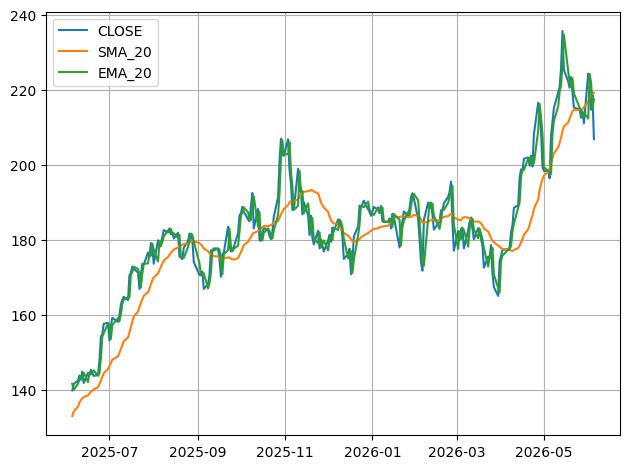

In [8]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
plt.plot(recent['close'],label='CLOSE')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['ema_20'],label='EMA_20')
display(recent)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [9]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

delta    = df['close'].diff()
#print(delta)
gain     = delta.clip(lower=0)
#print(gain)
loss     = -delta.clip(upper=0)
#print(loss)
n = 14
avg_gain = gain.ewm(com=n-1,adjust=False).mean()
avg_loss = loss.ewm(com=n-1,adjust=False).mean()
rs       = avg_gain / avg_loss
df['rsi_14'] = 100 - 100/(1+rs)
df['rsi_14'] = df['rsi_14']/100

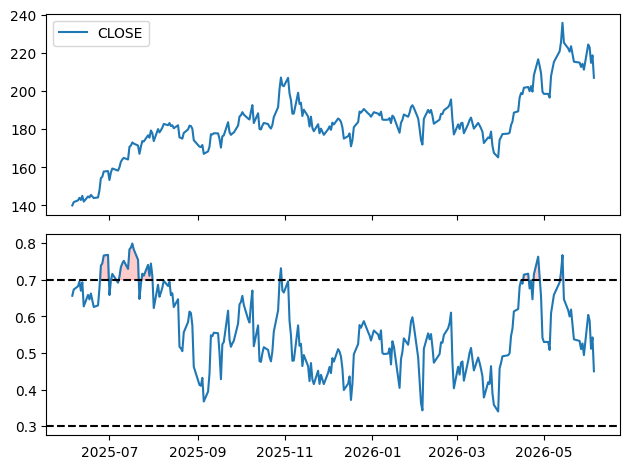

In [10]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]

close = recent['close']
rsi = recent['rsi_14']

fig,ax = plt.subplots(2,1,sharex=True)

ax[0].plot(recent.index,close,label='CLOSE')
ax[0].legend()

ax[1].plot(recent.index,rsi,label='RSI')

ax[1].axhline(0.7,linestyle='--',color='black')
ax[1].axhline(0.3,linestyle='--',color='black')

ax[1].fill_between(
    recent.index,rsi,0.7,where=(rsi>=0.7),color='red',alpha=0.2,label='OVERBROUGHT'
)

ax[1].fill_between(
    recent.index,rsi, 0.3,where=(rsi <= 0.3),color='green',alpha=0.2,label='OVERSOLD'
)
plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [11]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9,adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']
df

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,...,sma_ratio_20,sma_ratio_50,ema_12,ema_20,ema_26,ema_ratio_20,rsi_14,macd,macd_signal,macd_hist
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034,...,NaN,NaN,0.501942,0.502440,0.502620,-0.015306,0.000000,-0.000678,-0.000678,0.000000
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787,...,NaN,NaN,0.492442,0.493321,0.493639,-0.027510,0.000000,-0.001197,-0.000782,-0.000415
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609,...,NaN,NaN,0.479558,0.479631,0.479657,-0.002358,0.000000,-0.000100,-0.000645,0.000546
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927,...,NaN,NaN,0.481269,0.480214,0.479833,0.033913,0.141318,0.001436,-0.000229,0.001665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,...,1.035093,1.120317,213.173846,212.399047,212.119259,0.056314,0.603911,1.054587,0.138212,0.916375
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,...,1.022248,1.107086,224.123079,224.213335,224.245927,-0.006214,0.587901,-0.122848,0.086000,-0.208849
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,...,0.981118,1.062859,221.578468,222.051435,222.222229,-0.032882,0.511396,-0.643761,-0.059952,-0.583809


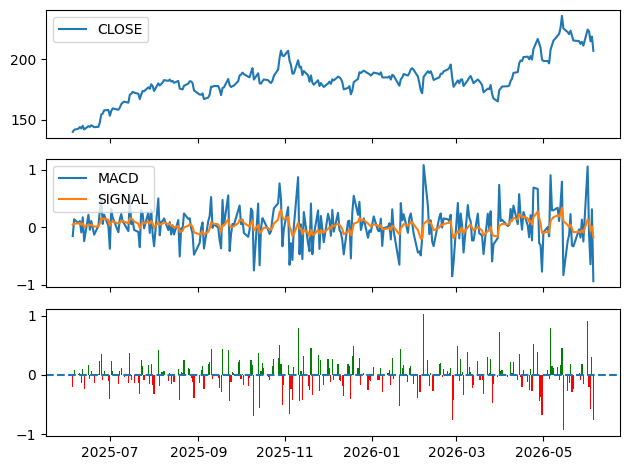

In [12]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
close = recent['close']
macd = recent['macd']
signal = recent['macd_signal']
hist = recent['macd_hist']
colors = np.where(hist >= 0,'green','red')

fig,axis = plt.subplots(3,1,sharex=True)
axis[0].plot(recent.index,close,label='CLOSE')
axis[0].legend()

axis[1].plot(recent.index,macd,label='MACD')
axis[1].plot(recent.index,signal,label='SIGNAL')
axis[1].legend()

axis[2].bar(recent.index,hist,color=colors)
axis[2].axhline(0, linestyle='--')

plt.tight_layout()
plt.show()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [13]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = df['close'].rolling(20).std()
df['bb_upper'] = df['sma_20'] + 2 * rolling_std
df['bb_lower'] = df['sma_20'] - 2 * rolling_std 
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['close']
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
df['bb_pct_b'] = df['bb_pct_b'].clip(0,1) 
# clip to [0, 1] optional but useful

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [14]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = (df['close'] - df['close'].shift(5)) / df['close'].shift(5) * 100
df['roc_10'] = (df['close'] - df['close'].shift(10)) / df['close'].shift(10) * 100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [15]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = df['close'].shift(1)
tr1 = df['high'] - df['low']
tr2 = (df['high'] - prev_close).abs()
tr3 = (df['low'] - prev_close).abs()
true_range = pd.concat([tr1,tr2,tr3],axis=1).max(axis=1)
df['atr_14']    = true_range.ewm(com=13,adjust=False).mean()
df['atr_ratio'] = df['atr_14'] / df['close']
display(df)

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,...,macd_signal,macd_hist,bb_upper,bb_lower,bb_width,bb_pct_b,roc_5,roc_10,atr_14,atr_ratio
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011750,0.023348
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034,...,-0.000678,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.011786,0.023822
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787,...,-0.000782,-0.000415,NaN,NaN,NaN,NaN,NaN,NaN,0.012140,0.025306
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609,...,-0.000645,0.000546,NaN,NaN,NaN,NaN,NaN,NaN,0.012023,0.025127
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927,...,-0.000229,0.001665,NaN,NaN,NaN,NaN,NaN,NaN,0.012664,0.025507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,...,0.138212,0.916375,235.167004,198.339998,0.164142,0.706547,4.193563,-0.426064,7.605820,0.033900
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,...,0.086000,-0.208849,234.410382,201.530622,0.147562,0.647492,3.704741,0.224901,7.843261,0.035200
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,...,-0.059952,-0.583809,231.994001,205.772002,0.122105,0.342384,1.011286,-2.656272,7.876600,0.036678


## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [16]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].rolling(14).min()
highest_high = df['high'].rolling(14).max()
df['stoch_k'] = (df['close'] - lowest_low) / (highest_high - lowest_low)
df['stoch_d'] = df['stoch_k'].rolling(3).mean()

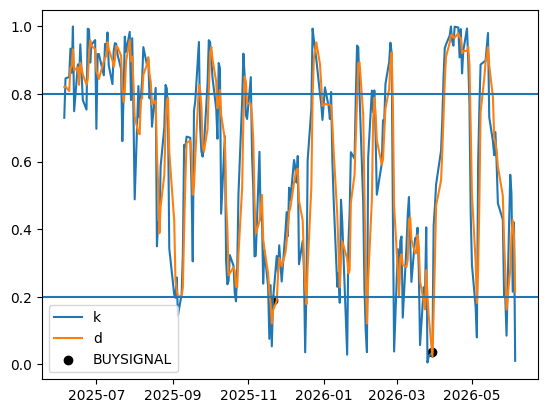

In [17]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent = df[df.index >= df.index.max() - pd.DateOffset(years=1)]
k = recent['stoch_k']
d = recent['stoch_d']
plt.plot(recent.index,k,label='k')
plt.plot(recent.index,d,label='d')
plt.axhline(0.8)
plt.axhline(0.2)

buy_signal = ((k > d) & (k.shift(1) < d.shift(1)) & (k < 0.2))
plt.scatter(recent.index[buy_signal],k[buy_signal],label='BUYSIGNAL',color='black')
plt.legend()
plt.show()


## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [18]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(close.diff())
obv_chan = direction * df['volume']
df['obv']       = obv_chan.cumsum()
df['obv_change']= (df['obv'].diff()) / df['obv'].shift(1).abs()
df

,adj_close,close,high,low,open,volume,symbol,return_1,return_5,log_return_1,...,bb_width,bb_pct_b,roc_5,roc_10,atr_14,atr_ratio,stoch_k,stoch_d,obv,obv_change
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.503250,0.507000,0.495250,0.503250,113680000,NVDA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.011750,0.023348,NaN,NaN,NaN,NaN
2015-01-05,0.474275,0.494750,0.504750,0.492500,0.503250,197952000,NVDA,-0.016890,NaN,-0.017034,...,NaN,NaN,NaN,NaN,0.011786,0.023822,NaN,NaN,NaN,NaN
2015-01-06,0.459896,0.479750,0.496000,0.479250,0.495500,197764000,NVDA,-0.030318,NaN,-0.030787,...,NaN,NaN,NaN,NaN,0.012140,0.025306,NaN,NaN,NaN,NaN
2015-01-07,0.458697,0.478500,0.487500,0.477000,0.483250,321808000,NVDA,-0.002606,NaN,-0.002609,...,NaN,NaN,NaN,NaN,0.012023,0.025127,NaN,NaN,NaN,NaN
2015-01-08,0.475952,0.496500,0.499500,0.483750,0.484000,283780000,NVDA,0.037618,NaN,0.036927,...,NaN,NaN,NaN,NaN,0.012664,0.025507,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01,224.098816,224.360001,224.869995,215.699997,215.729996,212850700,NVDA,0.062612,0.041936,0.060730,...,0.164142,0.706547,4.193563,-0.426064,7.605820,0.033900,0.561239,0.281100,3.024437e+09,0.075705
2026-06-02,222.560608,222.820007,232.279999,221.350006,227.179993,193362900,NVDA,-0.006864,0.037047,-0.006888,...,0.147562,0.647492,3.704741,0.224901,7.843261,0.035200,0.505764,0.384006,2.831074e+09,-0.063934
2026-06-03,214.500000,214.750000,222.820007,214.509995,221.720001,160907000,NVDA,-0.036218,0.010113,-0.036890,...,0.122105,0.342384,1.011286,-2.656272,7.876600,0.036678,0.215058,0.427354,2.670167e+09,-0.056836


## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [19]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (df['high'] + df['low'] + df['close']) / 3
tp_vol          = typical_price * df['volume']
df['vwap']       = tp_vol.rolling(20).sum() / df['volume'].rolling(20).sum()
df['vwap_ratio'] = df['close'] / df['vwap'] - 1
df.columns

Index(['adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol',
       'return_1', 'return_5', 'log_return_1', 'sma_20', 'sma_50', 'sma_200',
       'sma_ratio_20', 'sma_ratio_50', 'ema_12', 'ema_20', 'ema_26',
       'ema_ratio_20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
       'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b', 'roc_5', 'roc_10',
       'atr_14', 'atr_ratio', 'stoch_k', 'stoch_d', 'obv', 'obv_change',
       'vwap', 'vwap_ratio'],
      dtype='str')

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [20]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio','future_return','target_direction'
]

In [21]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = df['close'].shift(-1) / df['close'] - 1
df['target_direction'] = (df['future_return'] > 0).astype(int)

required = FEATURE_COLUMNS
df       = df.replace([np.inf,-np.inf],np.nan)
df_clean = df.dropna(subset=required).copy()
df_clean = df_clean.reset_index()
out_path = PROCESSED_DIR/f'{safe_symbol(symbol)}_features.csv'
df_clean.to_csv(out_path)
print(f'SAVED {safe_symbol(symbol)}.csv')
display(df_clean[required].describe().round(4))

SAVED NVDA_csv.csv


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000,249.0000
mean,0.0020,0.0099,0.0017,1.0182,1.0537,0.0017,0.5638,0.0246,0.0254,0.9882,1.9966,0.1318,0.5998,0.0306,0.6066,0.6084,0.0217,0.0192,0.0017,0.5341
std,0.0216,0.0448,0.0216,0.0432,0.0773,0.0195,0.1058,0.3231,0.0936,4.4799,5.7450,0.0442,0.2874,0.0051,0.2837,0.2609,0.1516,0.0438,0.0219,0.4998
min,-0.0546,-0.1072,-0.0561,0.9250,0.9023,-0.0496,0.3399,-0.8512,-0.1972,-10.7163,-10.4352,0.0544,0.0000,0.0213,0.0056,0.0218,-0.4724,-0.0759,-0.0546,0.0000
25%,-0.0102,-0.0202,-0.0103,0.9883,0.9947,-0.0092,0.4859,-0.1468,-0.0391,-2.0151,-2.3452,0.1034,0.3907,0.0270,0.3653,0.3643,-0.0737,-0.0124,-0.0103,0.0000
50%,0.0024,0.0082,0.0024,1.0131,1.0339,0.0022,0.5479,0.0343,0.0291,0.8227,1.4786,0.1221,0.6258,0.0301,0.6598,0.6623,0.0511,0.0155,0.0024,1.0000
75%,0.0159,0.0392,0.0158,1.0467,1.1203,0.0144,0.6542,0.2258,0.0821,3.9227,5.8745,0.1562,0.8449,0.0337,0.8554,0.8446,0.0883,0.0483,0.0159,1.0000
max,0.0787,0.1484,0.0758,1.1350,1.2263,0.0707,0.7988,1.0793,0.3419,14.8436,18.9744,0.2540,1.0000,0.0483,1.0000,0.9799,1.2021,0.1417,0.0787,1.0000


In [ ]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in ...:
    sym = ...
    try:
        raw       = ...
        # ... compute all indicators on raw ...
        processed = ...
        # ... save to PROCESSED_DIR ...
        summary.append({...})
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

---
